# 🧠 NOTEBOOK 1 — Data Preparation + EDA
## Paper: Explainable AI for Cross-Platform Depression Detection

---
### 📦 Add BOTH datasets before running:
| Dataset | Kaggle Link |
|---------|------------|
| Reddit  | `infamouscoder/depression-reddit-cleaned` |
| Twitter | `infamouscoder/mental-health-social-media` |

**How to add:** Right sidebar → `+ Add Input` → Search dataset name → Add

### ⚙️ Settings: GPU T4 ON | Internet ON


## STEP 1 — Install Libraries

In [1]:
# Pin versions to avoid huggingface conflicts
!pip install transformers==4.35.0 -q
!pip install huggingface-hub==0.20.3 -q
!pip install accelerate==0.24.1 -q
!pip install tokenizers==0.14.1 -q
!pip install imbalanced-learn -q
!pip install wordcloud -q
!pip install lime -q
print("✅ All done!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 101.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 24.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.8.3 requires huggingface-hub<2.0,>=0.25.0, but you have huggingface-hub 0.17.3 which is incompatible.
peft 0.18.1 requires huggingface_hub>=0.25.0, but you have huggingface-hub 0.17.3 which is incompatible.
sentence-transformers 5.2.3 requires huggingface-hub>=0.20.0, but you have huggingface-hub 0.17.3 which is incompatible.
sentence-transformers 5.2.3 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.35.0 which is incompatible.
accelerate 1.12.0 requires huggingface_hub>=0.2

## STEP 2 — Import All Libraries

In [2]:
import numpy as np
import pandas as pd
import os, re, warnings, pickle
warnings.filterwarnings('ignore')
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ PyTorch : {torch.__version__}")
print(f"✅ Device  : {device}")
print(f"✅ Imports done!")

✅ PyTorch : 2.10.0+cu128
✅ Device  : cuda
✅ Imports done!


## STEP 3 — Load Reddit Dataset

In [3]:
# ── Scan all input files ──
print("📁 All input files:")
all_csvs = []
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        fp = os.path.join(root, f)
        print(f"  {fp}")
        if f.endswith('.csv'):
            all_csvs.append(fp)
print(f"\nTotal CSVs: {len(all_csvs)}")

📁 All input files:
  /kaggle/input/datasets/infamouscoder/mental-health-social-media/Mental-Health-Twitter.csv
  /kaggle/input/datasets/infamouscoder/depression-reddit-cleaned/depression_dataset_reddit_cleaned.csv

Total CSVs: 2


In [4]:
# ── Find Reddit CSV ──
REDDIT_PATH = None
for path in all_csvs:
    try:
        df_test = pd.read_csv(path, nrows=2)
        if 'clean_text' in df_test.columns and 'is_depression' in df_test.columns:
            REDDIT_PATH = path
            print(f"✅ Reddit found: {path}")
            break
    except:
        continue

# Fallback by filename
if REDDIT_PATH is None:
    for path in all_csvs:
        if 'reddit' in path.lower() or 'depression_dataset' in path.lower():
            REDDIT_PATH = path
            print(f"✅ Reddit found by name: {path}")
            break

assert REDDIT_PATH is not None, "❌ Reddit CSV not found! Add dataset: infamouscoder/depression-reddit-cleaned"

reddit_df = pd.read_csv(REDDIT_PATH)
print(f"\nShape   : {reddit_df.shape}")
print(f"Columns : {reddit_df.columns.tolist()}")
print(f"Labels  :\n{reddit_df['is_depression'].value_counts().to_string()}")
print(f"\nSample  : {reddit_df['clean_text'].iloc[0][:100]}")

✅ Reddit found: /kaggle/input/datasets/infamouscoder/depression-reddit-cleaned/depression_dataset_reddit_cleaned.csv

Shape   : (7731, 2)
Columns : ['clean_text', 'is_depression']
Labels  :
is_depression
0    3900
1    3831

Sample  : we understand that most people who reply immediately to an op with an invitation to talk privately m


## STEP 4 — Load Twitter Dataset

In [5]:
# ── Find Twitter CSV (infamouscoder/mental-health-social-media) ──
# This dataset has columns: post_text | label (0/1)
TWITTER_PATH = None

for path in all_csvs:
    if path == REDDIT_PATH:
        continue
    try:
        df_test = pd.read_csv(path, nrows=3)
        cols = df_test.columns.tolist()
        # Check for known Twitter dataset columns
        if 'post_text' in cols:
            TWITTER_PATH = path
            print(f"✅ Twitter found (post_text col): {path}")
            break
        # Check for any text+label combo that's NOT reddit
        has_text  = any(c in cols for c in ['tweet','text','post_text','sentence'])
        has_label = any(c in cols for c in ['label','Label','is_depression','target'])
        if has_text and has_label and 'clean_text' not in cols:
            TWITTER_PATH = path
            print(f"✅ Twitter found (auto-detect): {path}")
            break
    except:
        continue

# Fallback by path keyword
if TWITTER_PATH is None:
    for path in all_csvs:
        if path == REDDIT_PATH:
            continue
        if any(k in path.lower() for k in ['social','twitter','mental','tweet']):
            TWITTER_PATH = path
            print(f"✅ Twitter found by name: {path}")
            break

# Last fallback — use any remaining CSV
if TWITTER_PATH is None:
    remaining = [p for p in all_csvs if p != REDDIT_PATH]
    if remaining:
        TWITTER_PATH = remaining[0]
        print(f"✅ Twitter fallback: {TWITTER_PATH}")

assert TWITTER_PATH is not None, "❌ Twitter CSV not found! Add: infamouscoder/mental-health-social-media"

twitter_df = pd.read_csv(TWITTER_PATH)
print(f"\nShape   : {twitter_df.shape}")
print(f"Columns : {twitter_df.columns.tolist()}")
print(f"\nFirst 3 rows:")
print(twitter_df.head(3).to_string())

✅ Twitter found (post_text col): /kaggle/input/datasets/infamouscoder/mental-health-social-media/Mental-Health-Twitter.csv

Shape   : (20000, 11)
Columns : ['Unnamed: 0', 'post_id', 'post_created', 'post_text', 'user_id', 'followers', 'friends', 'favourites', 'statuses', 'retweets', 'label']

First 3 rows:
   Unnamed: 0             post_id                    post_created                                                                                                                                     post_text     user_id  followers  friends  favourites  statuses  retweets  label
0           0  637894677824413696  Sun Aug 30 07:48:37 +0000 2015  It's just over 2 years since I was diagnosed with #anxiety and #depression. Today I'm taking a moment to reflect on how far I've come since.  1013187241         84      211         251       837         0      1
1           1  637890384576778240  Sun Aug 30 07:31:33 +0000 2015                                               It's Sunday, I need a 

In [6]:
# ── Auto-detect Twitter text + label columns ──
def find_text_col(df):
    priority = ['post_text','tweet','text','Text','Tweet',
                'sentence','content','message','body']
    for c in priority:
        if c in df.columns:
            return c
    # Fallback: longest avg string col
    str_cols = df.select_dtypes(include='object').columns
    if len(str_cols) > 0:
        return max(str_cols, key=lambda c: df[c].dropna().str.len().mean())
    raise ValueError("No text column found!")

def find_label_col(df, text_col):
    priority = ['label','Label','is_depression','depression',
                'target','class','Category','sentiment']
    for c in priority:
        if c in df.columns and c != text_col:
            return c
    # Fallback: fewest unique values (excluding text col)
    other = [c for c in df.columns if c != text_col]
    return min(other, key=lambda c: df[c].nunique())

TWITTER_TEXT_COL  = find_text_col(twitter_df)
TWITTER_LABEL_COL = find_label_col(twitter_df, TWITTER_TEXT_COL)

print(f"✅ Text column  : '{TWITTER_TEXT_COL}'")
print(f"✅ Label column : '{TWITTER_LABEL_COL}'")
print(f"\nUnique labels  : {twitter_df[TWITTER_LABEL_COL].unique()}")
print(f"Label counts   :\n{twitter_df[TWITTER_LABEL_COL].value_counts().to_string()}")

✅ Text column  : 'post_text'
✅ Label column : 'label'

Unique labels  : [1 0]
Label counts   :
label
1    10000
0    10000


In [7]:
# ── Build label map — handles ANY format ──
def build_label_map(series):
    unique = series.dropna().unique()
    print(f"  Raw unique values: {unique}")
    lmap = {}
    dep_pos   = {'1','1.0','depressed','depression','positive',
                 'yes','true','dep','anxiety','anxious','sad',
                 'mental illness','disorder'}
    dep_neg   = {'0','0.0','not depressed','no depression',
                 'negative','no','false','normal','healthy',
                 'not_depression','none','neutral'}
    for v in unique:
        v_str = str(v).strip().lower()
        if v_str in dep_pos:
            lmap[v] = 1
        elif v_str in dep_neg:
            lmap[v] = 0
        else:
            try:
                num = int(float(v_str))
                lmap[v] = 1 if num >= 1 else 0
            except:
                lmap[v] = None
                print(f"  ⚠️ Unknown label '{v}' → dropped")
    return lmap

print("Building label map for Twitter...")
lmap = build_label_map(twitter_df[TWITTER_LABEL_COL])
print(f"  Final map: {lmap}")

Building label map for Twitter...
  Raw unique values: [1 0]
  Final map: {np.int64(1): 1, np.int64(0): 0}


## STEP 5 — Standardize + Merge Both Datasets

In [8]:
# ════════════════════════════════════
# STANDARDIZE REDDIT
# ════════════════════════════════════
reddit_std = pd.DataFrame({
    'text'  : reddit_df['clean_text'].astype(str),
    'label' : reddit_df['is_depression'].astype(int),
    'source': 'reddit',
    'platform': 'Reddit'
})
print(f"Reddit : {len(reddit_std):,} rows | "
      f"Labels: {dict(reddit_std['label'].value_counts())}")

# ════════════════════════════════════
# STANDARDIZE TWITTER
# ════════════════════════════════════
twitter_std = pd.DataFrame({
    'text'  : twitter_df[TWITTER_TEXT_COL].astype(str),
    'label' : twitter_df[TWITTER_LABEL_COL].map(lmap),
    'source': 'twitter',
    'platform': 'Twitter'
})
twitter_std.dropna(subset=['label'], inplace=True)
twitter_std['label'] = twitter_std['label'].astype(int)
print(f"Twitter: {len(twitter_std):,} rows | "
      f"Labels: {dict(twitter_std['label'].value_counts())}")

# ════════════════════════════════════
# MERGE + CLEAN
# ════════════════════════════════════
combined = pd.concat([reddit_std, twitter_std], ignore_index=True)

before = len(combined)
combined.dropna(subset=['text','label'], inplace=True)
combined.drop_duplicates(subset='text', inplace=True)
combined['label'] = combined['label'].astype(int)
combined['text']  = combined['text'].astype(str)
combined = combined[combined['text'].str.split().str.len() >= 3]
combined.reset_index(drop=True, inplace=True)

print()
print("="*55)
print("   ✅ MERGED CROSS-PLATFORM CORPUS")
print("="*55)
print(f"  Total (clean)  : {len(combined):,}")
print(f"  Removed (dirty): {before-len(combined):,}")
print(f"  Reddit         : {(combined.source=='reddit').sum():,}")
print(f"  Twitter        : {(combined.source=='twitter').sum():,}")
print(f"  Depressed [1]  : {(combined.label==1).sum():,}")
print(f"  Not Dep   [0]  : {(combined.label==0).sum():,}")
print(f"  Balance        : {combined.label.mean():.2%} depressed")
print("="*55)

Reddit : 7,731 rows | Labels: {0: np.int64(3900), 1: np.int64(3831)}
Twitter: 20,000 rows | Labels: {1: np.int64(10000), 0: np.int64(10000)}

   ✅ MERGED CROSS-PLATFORM CORPUS
  Total (clean)  : 26,233
  Removed (dirty): 1,498
  Reddit         : 7,578
  Twitter        : 18,655
  Depressed [1]  : 13,510
  Not Dep   [0]  : 12,723
  Balance        : 51.50% depressed


## STEP 6 — Add Text Features for EDA

In [9]:
# Add text statistics
combined['text_len']     = combined['text'].str.len()
combined['word_count']   = combined['text'].str.split().str.len()
combined['avg_word_len'] = combined['text'].apply(
    lambda t: np.mean([len(w) for w in t.split()]) if t.split() else 0)
combined['has_question'] = combined['text'].str.contains(r'\?').astype(int)
combined['has_exclaim']  = combined['text'].str.contains(r'!').astype(int)
combined['sentence_count'] = combined['text'].str.count(r'[.!?]+') + 1

print("✅ Text features added!")
print(combined[['text_len','word_count','avg_word_len']].describe().round(2).to_string())

✅ Text features added!
       text_len  word_count  avg_word_len
count  26233.00    26233.00      26233.00
mean     165.04       30.87          5.49
std      391.70       81.89          2.02
min       10.00        3.00          1.10
25%       54.00        8.00          4.07
50%       87.00       14.00          4.95
75%      132.00       21.00          6.36
max    19822.00     4239.00         25.67


## STEP 7 — Full EDA (8 Plots)

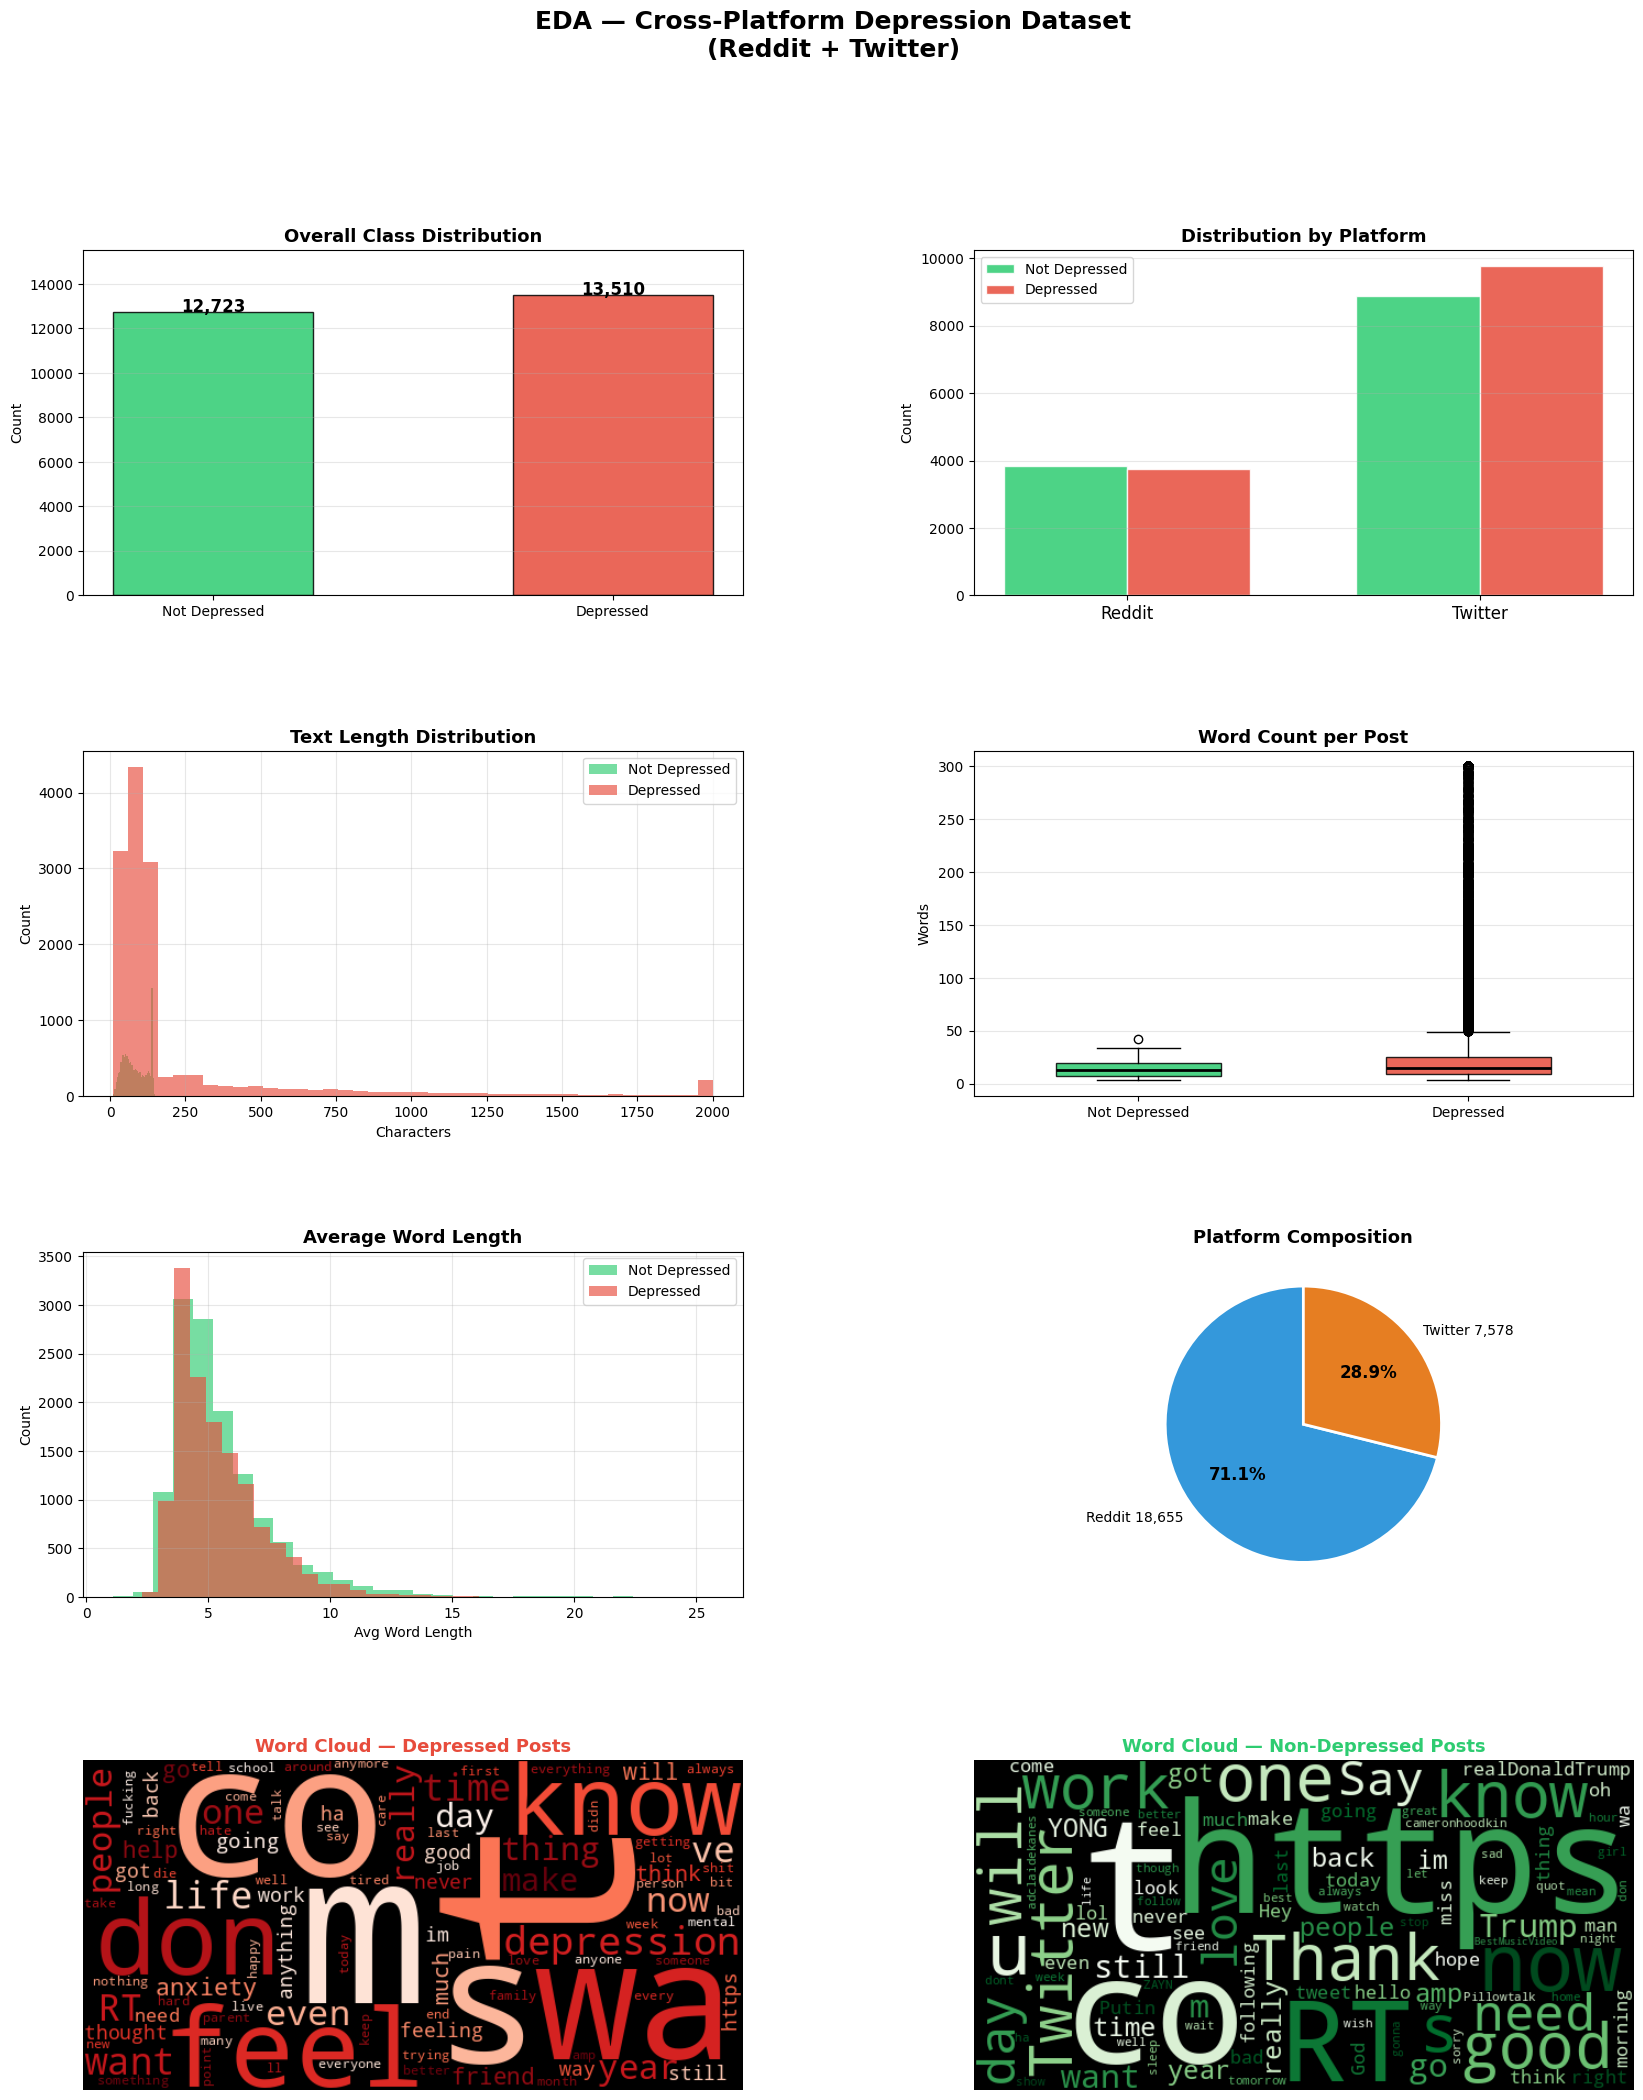

✅ EDA (8 plots) saved → eda_full.png


In [10]:
COLORS = ['#2ecc71','#e74c3c']   # green=not dep, red=dep
LABELS = ['Not Depressed','Depressed']

fig = plt.figure(figsize=(20, 24))
fig.suptitle('EDA — Cross-Platform Depression Dataset\n(Reddit + Twitter)',
             fontsize=18, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Plot 1: Overall class distribution ──
ax1 = fig.add_subplot(gs[0, 0])
vals = combined['label'].value_counts().sort_index()
bars = ax1.bar(LABELS, vals.values, color=COLORS,
               edgecolor='black', alpha=0.85, width=0.5)
ax1.set_title('Overall Class Distribution', fontweight='bold', fontsize=13)
ax1.set_ylabel('Count')
for bar, v in zip(bars, vals.values):
    ax1.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+20, f'{v:,}',
             ha='center', fontweight='bold', fontsize=12)
ax1.set_ylim(0, max(vals.values)*1.15)
ax1.grid(axis='y', alpha=0.3)

# ── Plot 2: Platform-wise distribution ──
ax2 = fig.add_subplot(gs[0, 1])
cross = combined.groupby(['source','label']).size().unstack(fill_value=0)
x = np.arange(len(cross)); w = 0.35
for i, (lbl, col) in enumerate(zip(LABELS, COLORS)):
    if i in cross.columns:
        bars2 = ax2.bar(x + (i-0.5)*w, cross[i], w,
                        label=lbl, color=col, alpha=0.85, edgecolor='white')
ax2.set_xticks(x)
ax2.set_xticklabels(['Reddit','Twitter'], fontsize=12)
ax2.set_title('Distribution by Platform', fontweight='bold', fontsize=13)
ax2.set_ylabel('Count')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)

# ── Plot 3: Text length distribution ──
ax3 = fig.add_subplot(gs[1, 0])
for lbl_val, col, name in zip([0,1], COLORS, LABELS):
    data = combined[combined.label==lbl_val]['text_len'].clip(upper=2000)
    ax3.hist(data, bins=40, alpha=0.65, color=col, label=name)
ax3.set_title('Text Length Distribution', fontweight='bold', fontsize=13)
ax3.set_xlabel('Characters'); ax3.set_ylabel('Count')
ax3.legend(); ax3.grid(alpha=0.3)

# ── Plot 4: Word count boxplot ──
ax4 = fig.add_subplot(gs[1, 1])
data_bp = [combined[combined.label==l]['word_count'].clip(upper=300)
           for l in [0,1]]
bp = ax4.boxplot(data_bp, patch_artist=True, labels=LABELS,
                 widths=0.5)
for patch, col in zip(bp['boxes'], COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.85)
for med in bp['medians']:
    med.set_color('black'); med.set_linewidth(2)
ax4.set_title('Word Count per Post', fontweight='bold', fontsize=13)
ax4.set_ylabel('Words')
ax4.grid(axis='y', alpha=0.3)

# ── Plot 5: Avg word length comparison ──
ax5 = fig.add_subplot(gs[2, 0])
for lbl_val, col, name in zip([0,1], COLORS, LABELS):
    data = combined[combined.label==lbl_val]['avg_word_len']
    ax5.hist(data, bins=30, alpha=0.65, color=col, label=name)
ax5.set_title('Average Word Length', fontweight='bold', fontsize=13)
ax5.set_xlabel('Avg Word Length'); ax5.set_ylabel('Count')
ax5.legend(); ax5.grid(alpha=0.3)

# ── Plot 6: Platform balance pie ──
ax6 = fig.add_subplot(gs[2, 1])
src_counts = combined['source'].value_counts()
wedge_cols = ['#3498db','#e67e22']
r_count = src_counts.iloc[0]
t_count = src_counts.iloc[1]
r_label = 'Reddit ' + f'{r_count:,}'
t_label = 'Twitter ' + f'{t_count:,}'
wp, tx, atx = ax6.pie(src_counts.values,
    labels=[r_label, t_label],
    autopct='%1.1f%%', colors=wedge_cols,
    startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
for a in atx:
    a.set_fontsize(12); a.set_fontweight('bold')
ax6.set_title('Platform Composition', fontweight='bold', fontsize=13)

# ── Plot 7: Depressed word cloud ──
ax7 = fig.add_subplot(gs[3, 0])
dep_text = ' '.join(
    combined[combined.label==1]['text'].dropna().sample(
        min(3000,(combined.label==1).sum()), random_state=42))
wc1 = WordCloud(width=600, height=300, background_color='black',
                colormap='Reds', max_words=100,
                collocations=False).generate(dep_text)
ax7.imshow(wc1, interpolation='bilinear')
ax7.axis('off')
ax7.set_title('Word Cloud — Depressed Posts',
              color='#e74c3c', fontweight='bold', fontsize=13)

# ── Plot 8: Not depressed word cloud ──
ax8 = fig.add_subplot(gs[3, 1])
nodep_text = ' '.join(
    combined[combined.label==0]['text'].dropna().sample(
        min(3000,(combined.label==0).sum()), random_state=42))
wc2 = WordCloud(width=600, height=300, background_color='black',
                colormap='Greens', max_words=100,
                collocations=False).generate(nodep_text)
ax8.imshow(wc2, interpolation='bilinear')
ax8.axis('off')
ax8.set_title('Word Cloud — Non-Depressed Posts',
              color='#2ecc71', fontweight='bold', fontsize=13)

plt.savefig('/kaggle/working/eda_full.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA (8 plots) saved → eda_full.png")

## STEP 8 — Extended EDA (Statistical Analysis)

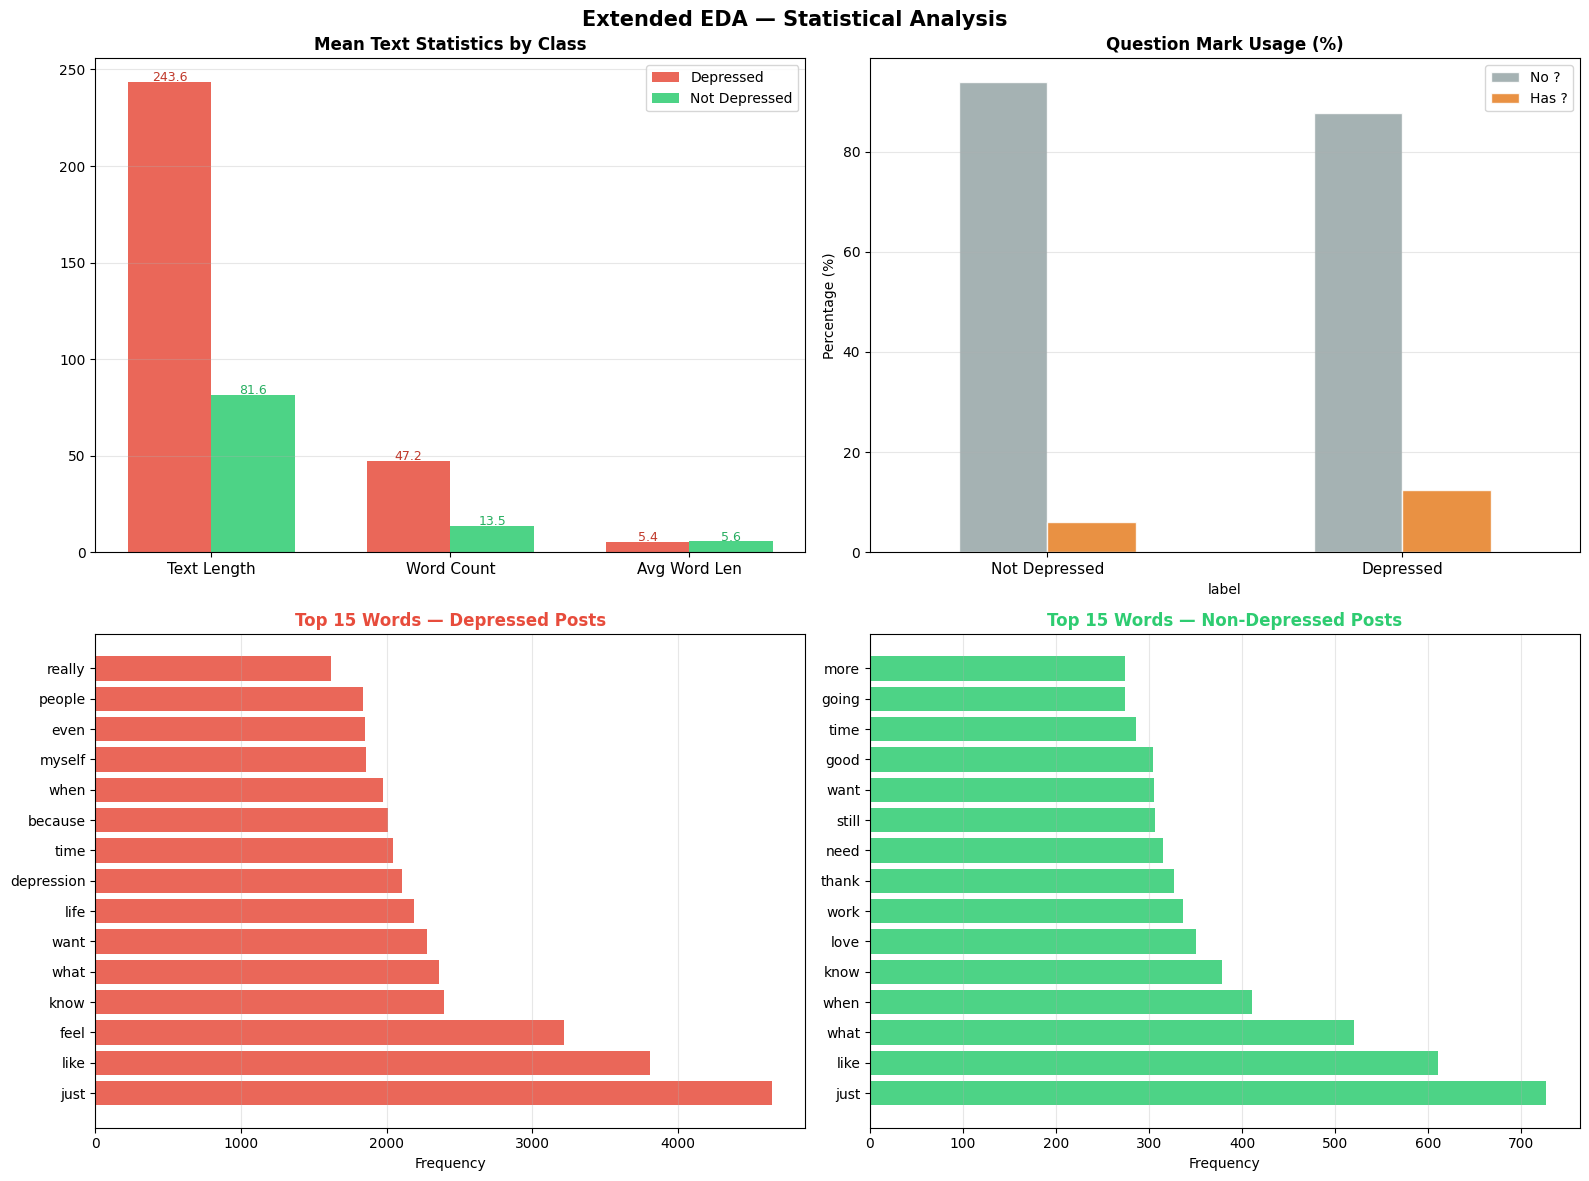

✅ Extended EDA saved → eda_extended.png

   STATISTICAL SUMMARY
  Text Length:
    Depressed     : 243.6
    Not Depressed : 81.6
    Difference    : +198.3%
  Word Count:
    Depressed     : 47.2
    Not Depressed : 13.5
    Difference    : +249.3%


In [11]:
fig2, axes = plt.subplots(2, 2, figsize=(16, 12))
fig2.suptitle('Extended EDA — Statistical Analysis',
              fontsize=15, fontweight='bold')

# ── Plot A: Mean text stats by class ──
ax = axes[0,0]
stats_cols = ['text_len','word_count','avg_word_len']
stats_labels = ['Text Length','Word Count','Avg Word Len']
dep_means   = [combined[combined.label==1][c].mean() for c in stats_cols]
nodep_means = [combined[combined.label==0][c].mean() for c in stats_cols]

x2 = np.arange(len(stats_labels)); w2 = 0.35
ax.bar(x2-w2/2, dep_means,   w2, label='Depressed',
       color='#e74c3c', alpha=0.85)
ax.bar(x2+w2/2, nodep_means, w2, label='Not Depressed',
       color='#2ecc71', alpha=0.85)
ax.set_xticks(x2); ax.set_xticklabels(stats_labels, fontsize=11)
ax.set_title('Mean Text Statistics by Class',
             fontweight='bold', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
for xi, (d, nd) in enumerate(zip(dep_means, nodep_means)):
    ax.text(xi-w2/2, d+0.5, f'{d:.1f}', ha='center', fontsize=9, color='#c0392b')
    ax.text(xi+w2/2, nd+0.5, f'{nd:.1f}', ha='center', fontsize=9, color='#27ae60')

# ── Plot B: Question marks usage ──
ax2b = axes[0,1]
q_data = combined.groupby(['label','has_question']).size().unstack(fill_value=0)
q_pct  = q_data.div(q_data.sum(axis=1), axis=0) * 100
q_pct.plot(kind='bar', ax=ax2b, color=['#95a5a6','#e67e22'],
           edgecolor='white', alpha=0.85)
ax2b.set_xticklabels(LABELS, rotation=0, fontsize=11)
ax2b.set_title('Question Mark Usage (%)',
               fontweight='bold', fontsize=12)
ax2b.set_ylabel('Percentage (%)')
ax2b.legend(['No ?','Has ?']); ax2b.grid(axis='y', alpha=0.3)

# ── Plot C: Top 15 most frequent words per class ──
ax3b = axes[1,0]
from collections import Counter

STOPWORDS = {'the','a','an','and','or','but','in','on','at',
             'to','for','of','with','is','was','are','were',
             'be','been','being','have','has','had','do','does',
             'did','will','would','could','should','may','might',
             'it','its','this','that','these','those','i','my',
             'me','we','our','you','your','he','she','they','their',
             'not','no','so','if','as','by','from','up','about'}

dep_words   = []
nodep_words = []
for txt, lbl in zip(combined['text'], combined['label']):
    words = [w.lower() for w in str(txt).split()
             if w.lower() not in STOPWORDS and len(w) > 3]
    if lbl == 1:
        dep_words.extend(words)
    else:
        nodep_words.extend(words)

top_dep   = Counter(dep_words).most_common(15)
top_nodep = Counter(nodep_words).most_common(15)

words_d, cnt_d = zip(*top_dep)   if top_dep   else ([],[])
words_n, cnt_n = zip(*top_nodep) if top_nodep else ([],[])

ax3b.barh(range(len(words_d)), cnt_d,
          color='#e74c3c', alpha=0.85)
ax3b.set_yticks(range(len(words_d)))
ax3b.set_yticklabels(words_d, fontsize=10)
ax3b.set_title('Top 15 Words — Depressed Posts',
               color='#e74c3c', fontweight='bold', fontsize=12)
ax3b.set_xlabel('Frequency')
ax3b.grid(axis='x', alpha=0.3)

# ── Plot D: Top 15 words — not depressed ──
ax4b = axes[1,1]
ax4b.barh(range(len(words_n)), cnt_n,
          color='#2ecc71', alpha=0.85)
ax4b.set_yticks(range(len(words_n)))
ax4b.set_yticklabels(words_n, fontsize=10)
ax4b.set_title('Top 15 Words — Non-Depressed Posts',
               color='#2ecc71', fontweight='bold', fontsize=12)
ax4b.set_xlabel('Frequency')
ax4b.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/eda_extended.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Extended EDA saved → eda_extended.png")

# ── Print stats summary ──
print()
print("="*55)
print("   STATISTICAL SUMMARY")
print("="*55)
for col, name in zip(['text_len','word_count'],
                     ['Text Length','Word Count']):
    d  = combined[combined.label==1][col].mean()
    nd = combined[combined.label==0][col].mean()
    diff = ((d-nd)/nd)*100
    print(f"  {name}:")
    print(f"    Depressed     : {d:.1f}")
    print(f"    Not Depressed : {nd:.1f}")
    print(f"    Difference    : {diff:+.1f}%")
print("="*55)

## STEP 9 — Platform-Aware Preprocessing

In [12]:
def clean_reddit(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[\n\r\t]+', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

def clean_twitter(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.lower().strip()

print("Cleaning texts (platform-aware)...")
combined['clean_text'] = combined.apply(
    lambda r: clean_reddit(r['text'])
              if r['source']=='reddit'
              else clean_twitter(r['text']),
    axis=1)

# Remove too-short after cleaning
combined = combined[
    combined['clean_text'].str.split().str.len() >= 3]
combined.reset_index(drop=True, inplace=True)

print(f"✅ After preprocessing: {len(combined):,} samples")
print()
print("Cleaned samples:")
for i in range(3):
    src = combined['source'].iloc[i]
    lbl = combined['label'].iloc[i]
    txt = combined['clean_text'].iloc[i]
    print(f"  [{src}][{'DEP' if lbl==1 else 'NO '}] {txt[:80]}...")

Cleaning texts (platform-aware)...
✅ After preprocessing: 25,429 samples

Cleaned samples:
  [reddit][DEP] we understand that most people who reply immediately to an op with an invitation...
  [reddit][DEP] welcome to r depression s check in post a place to take a moment and share what ...
  [reddit][DEP] anyone else instead of sleeping more when depressed stay up all night to avoid t...


## STEP 10 — Class Balancing

In [13]:
print("Before balancing:")
vc = combined['label'].value_counts()
print(vc.to_string())
print(f"Imbalance ratio: {vc.max()/vc.min():.2f}x")
print()

dep    = combined[combined.label==1]
no_dep = combined[combined.label==0]
n      = min(len(dep), len(no_dep))

balanced = pd.concat([
    dep.sample(n=n, random_state=42),
    no_dep.sample(n=n, random_state=42)
]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"After balancing (n={n:,} per class):")
print(balanced['label'].value_counts().to_string())
print(f"Total: {len(balanced):,}")
print()
print("Platform breakdown (balanced):")
print(balanced.groupby(['source','label']).size().to_string())

Before balancing:
label
1    13142
0    12287
Imbalance ratio: 1.07x

After balancing (n=12,287 per class):
label
1    12287
0    12287
Total: 24,574

Platform breakdown (balanced):
source   label
reddit   0        3835
         1        3508
twitter  0        8452
         1        8779


## STEP 11 — LIWC Psycholinguistic Features

Extracting LIWC features...
✅ LIWC matrix: (24574, 12)


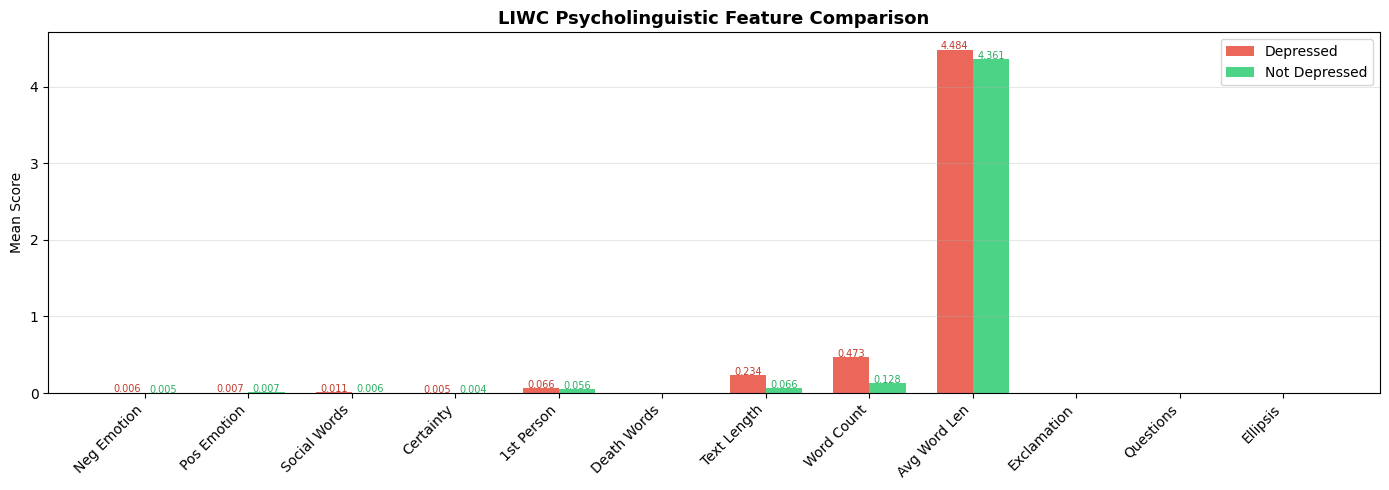

✅ LIWC plot saved → liwc_comparison.png


In [14]:
# ── Clinically validated word lists ──
NEG_EMO = {
    'sad','hopeless','worthless','empty','numb','miserable',
    'depressed','anxious','lonely','tired','exhausted','broken',
    'hurt','pain','crying','suffer','awful','terrible','horrible',
    'useless','failure','hate','desperate','helpless','trapped',
    'hollow','shattered','defeated','overwhelmed','distressed',
    'gloomy','melancholy','grief','sorrow','despair','anguish'
}
POS_EMO = {
    'happy','joy','love','laugh','smile','excited','wonderful',
    'amazing','grateful','hope','glad','enjoy','fun','celebrate',
    'blessed','proud','peaceful','content','cheerful','delight',
    'thrilled','pleased','optimistic','thankful','fantastic'
}
SOCIAL = {
    'friend','family','together','talk','share','support',
    'people','someone','anyone','everyone','community',
    'connect','relationship','team','partner','group'
}
CERTAINTY = {
    'always','never','nothing','everything','forever','nobody',
    'completely','totally','absolutely','definitely','impossible',
    'endless','constant','permanent','inevitable','certain'
}
FIRST_P = {'i','me','my','myself','mine','im','ive','ill','id'}
DEATH_W = {
    'die','death','dead','kill','suicide','end','gone',
    'disappear','pointless','meaningless','worthless','void','cease'
}

LIWC_NAMES = [
    'Neg Emotion','Pos Emotion','Social Words',
    'Certainty','1st Person','Death Words',
    'Text Length','Word Count','Avg Word Len',
    'Exclamation','Questions','Ellipsis'
]

def extract_liwc(text):
    words = text.lower().split()
    n = max(len(words), 1)
    return [
        sum(w in NEG_EMO   for w in words)/n,
        sum(w in POS_EMO   for w in words)/n,
        sum(w in SOCIAL    for w in words)/n,
        sum(w in CERTAINTY for w in words)/n,
        sum(w in FIRST_P   for w in words)/n,
        sum(w in DEATH_W   for w in words)/n,
        len(text)/1000.0,
        n/100.0,
        np.mean([len(w) for w in words]),
        text.count('!')/n,
        text.count('?')/n,
        text.count('...')/n,
    ]

print("Extracting LIWC features...")
liwc_all = np.array([extract_liwc(t)
                     for t in balanced['clean_text']])
print(f"✅ LIWC matrix: {liwc_all.shape}")

# ── LIWC Comparison Plot ──
dep_mask   = balanced['label'].values == 1
mu_dep     = liwc_all[dep_mask].mean(axis=0)
mu_nodep   = liwc_all[~dep_mask].mean(axis=0)

x3 = np.arange(len(LIWC_NAMES)); w3 = 0.35
fig3, ax = plt.subplots(figsize=(14, 5))
ax.bar(x3-w3/2, mu_dep,   w3, label='Depressed',
       color='#e74c3c', alpha=0.85)
ax.bar(x3+w3/2, mu_nodep, w3, label='Not Depressed',
       color='#2ecc71', alpha=0.85)
ax.set_xticks(x3)
ax.set_xticklabels(LIWC_NAMES, rotation=45, ha='right')
ax.set_title('LIWC Psycholinguistic Feature Comparison',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Score'); ax.legend(); ax.grid(axis='y', alpha=0.3)

# Add value labels
for xi,(d,nd) in enumerate(zip(mu_dep,mu_nodep)):
    if d > 0.004:
        ax.text(xi-w3/2, d+0.001, f'{d:.3f}',
                ha='center', fontsize=7, color='#c0392b')
    if nd > 0.004:
        ax.text(xi+w3/2, nd+0.001, f'{nd:.3f}',
                ha='center', fontsize=7, color='#27ae60')

plt.tight_layout()
plt.savefig('/kaggle/working/liwc_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ LIWC plot saved → liwc_comparison.png")

## STEP 12 — Train/Val/Test Split + Save

In [15]:
texts  = balanced['clean_text'].values
labels = balanced['label'].values

# 70 / 15 / 15
(X_train, X_temp,
 y_train, y_temp,
 lw_train, lw_temp) = train_test_split(
    texts, labels, liwc_all,
    test_size=0.30, stratify=labels, random_state=42)

(X_val, X_test,
 y_val, y_test,
 lw_val, lw_test) = train_test_split(
    X_temp, y_temp, lw_temp,
    test_size=0.50, stratify=y_temp, random_state=42)

print("Split Summary:")
print(f"  Train : {len(X_train):,} ({len(X_train)/len(texts)*100:.0f}%)")
print(f"  Val   : {len(X_val):,}  ({len(X_val)/len(texts)*100:.0f}%)")
print(f"  Test  : {len(X_test):,}  ({len(X_test)/len(texts)*100:.0f}%)")
print(f"  Train labels: {Counter(y_train)}")
print(f"  Val   labels: {Counter(y_val)}")
print(f"  Test  labels: {Counter(y_test)}")

# ── Save ──
processed_data = {
    'X_train':X_train, 'X_val':X_val, 'X_test':X_test,
    'y_train':y_train, 'y_val':y_val, 'y_test':y_test,
    'lw_train':lw_train, 'lw_val':lw_val, 'lw_test':lw_test,
    'LIWC_NAMES': LIWC_NAMES,
    'balanced':   balanced,
    'n_liwc':     int(lw_train.shape[1]),
}

SAVE_PATH = '/kaggle/working/processed_data.pkl'
with open(SAVE_PATH, 'wb') as f:
    pickle.dump(processed_data, f)

sz = os.path.getsize(SAVE_PATH)/(1024*1024)
print()
print("="*55)
print("   ✅ NOTEBOOK 1 COMPLETE!")
print("="*55)
print(f"   processed_data.pkl : {sz:.1f} MB")
print()
print("   Saved figures:")
print("   ✅ eda_full.png       (8 plots)")
print("   ✅ eda_extended.png   (4 plots)")
print("   ✅ liwc_comparison.png")
print()
print("   📌 Next Steps:")
print("   1. Output tab → Download processed_data.pkl")
print("   2. In NB2: Upload button → upload pkl")
print("   3. Run NB2!")
print("="*55)

Split Summary:
  Train : 17,201 (70%)
  Val   : 3,686  (15%)
  Test  : 3,687  (15%)
  Train labels: Counter({np.int64(1): 8601, np.int64(0): 8600})
  Val   labels: Counter({np.int64(1): 1843, np.int64(0): 1843})
  Test  labels: Counter({np.int64(0): 1844, np.int64(1): 1843})

   ✅ NOTEBOOK 1 COMPLETE!
   processed_data.pkl : 11.7 MB

   Saved figures:
   ✅ eda_full.png       (8 plots)
   ✅ eda_extended.png   (4 plots)
   ✅ liwc_comparison.png

   📌 Next Steps:
   1. Output tab → Download processed_data.pkl
   2. In NB2: Upload button → upload pkl
   3. Run NB2!
